# 📟 Stage 3 — On-Device Deployment & Measurement

**Project:** Energy-Aware Visual Anomaly Detection on MCUs — Stage 3 / 4

 - Takes the Stage 2 compressed models
 - converts them to TFLite INT8
 - deploys them on the **Arduino Nano 33 BLE Sense Rev 2**
 - measures real latency and memory
 - approximates energy per inference

## The two Parts of Stage 3

**Part A — in Colab:**
PyTorch → LiteRT → static full-integer INT8 conversion, with numerical verification that the TFLite output matches PyTorch, and conversion of each model to a C header array for the Arduino.

**Part B — on the Arduino (C++ firmware): 2 project folders under /Ondevice_Inference/ :**

- /arduino_stage3_OneModelInference/ : Load a model, run inference on a stored test image, report inference latency and memory.

- /arduino_stage3_StreamTestSet/ : Same but we stream the entire test set over the serial port.

### We measure...

The **simulated INT8** numbers from Stage 2 (theoretical size, weight-only fake-quant accuracy) are replaced by **real measurements**:

 - Actual TFLite INT8 model size
 - on-device latency (millis around Invoke)
 - SRAM arena (arena_used_bytes)
 - flash usage
 - true on-device AUROC.

Per-inference energy is estimated from measured latency and the nRF52840 datasheet active current.

(*CPU running CoreMark @64 MHz from flash: 6.3 mA at 3.3 V, ∼20.8 mW*)

❌The Stage 2 Pareto plot gets its size/energy axes updated with hardware truth.

---

PyTorch model
      ↓
LiteRT / TFLite FP32
      ↓
Calibration
      ↓
Full INT8 TFLite
      ↓
C header
      ↓
Arduino firmware

# Zone 1 — Setup

## 1. Install conversion toolchain
Restart the runtime once if imports fail in the next cell (TF + litert-torch).

In [1]:
!pip install litert-torch
!pip install -U tensorflow==2.20.0 keras==3.10.0
!pip install -q ai-edge-quantizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.8/575.8 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.3/419.3 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.6/117.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 25.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_e

In [ ]:
!pip list | grep -E "tensorflow|keras|ai-edge|litert|numpy|ml-dtypes"

ai-edge-litert                           2.1.5
ai-edge-quantizer                        0.7.0
keras                                    3.10.0
keras-hub                                0.26.0
keras-nlp                                0.26.0
litert-converter                         0.2.0
litert-lm-builder                        0.13.0
litert-torch                             0.9.1
numpy                                    2.0.2
tensorflow                               2.20.0
tensorflow-datasets                      4.9.10
tensorflow-hub                           0.16.1
tensorflow-metadata                      1.21.0
tensorflow-probability                   0.25.0
tensorflow-text                          2.20.1
tf_keras                                 2.20.0


## 2. Imports, Drive, config

We import all of our models made from Stage 2 and define the same protocol as previous stages.

In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

from google.colab import drive
drive.mount('/content/drive')

# symlink data
src = '/content/drive/MyDrive/mvtec'; dst = '/content/mvtec'
if os.path.islink(dst): os.unlink(dst)
elif os.path.isdir(dst): shutil.rmtree(dst)
os.symlink(src, dst)

# pull Stage 2 models from Drive
STAGE2_DIR = Path('/content/stage2_out'); STAGE2_DIR.mkdir(exist_ok=True)
drive_s2 = Path('/content/drive/MyDrive/mvtec_stage2')
for f in drive_s2.glob('*'):
    shutil.copy(f, STAGE2_DIR / f.name)

OUT = Path('/content/stage3_out'); OUT.mkdir(exist_ok=True)
(OUT / 'tflite').mkdir(exist_ok=True)
(OUT / 'headers').mkdir(exist_ok=True)

CFG = {'data_root': '/content/mvtec', 'image_size': 64,
       'base_channels': 32, 'latent_channels': 32, 'n_down': 3, 'batch_size': 32}
PROTOCOL = {'border': 4, 'blur_kernel': 5, 'pool': 'mean'}

print('Stage 2 models available:')
for f in sorted(STAGE2_DIR.glob('model_*.pt')): print('  ', f.name)

Mounted at /content/drive
Stage 2 models available:
   model_bottle_Baseline_FP32.pt
   model_bottle_Distill_b16.pt
   model_bottle_Distill_b16_plus_INT8.pt
   model_bottle_INT8_sim.pt
   model_bottle_Prune_30pct_l1.pt
   model_bottle_Prune_30pct_l1_plus_INT8.pt
   model_bottle_Prune_30pct_taylor.pt
   model_bottle_Prune_30pct_taylor_plus_INT8.pt
   model_bottle_Prune_50pct_l1.pt
   model_bottle_Prune_50pct_l1_plus_INT8.pt
   model_bottle_Prune_50pct_taylor.pt
   model_bottle_Prune_50pct_taylor_plus_INT8.pt
   model_hazelnut_Baseline_FP32.pt
   model_hazelnut_Distill_b16.pt
   model_hazelnut_Distill_b16_plus_INT8.pt
   model_hazelnut_INT8_sim.pt
   model_hazelnut_Prune_30pct_l1.pt
   model_hazelnut_Prune_30pct_l1_plus_INT8.pt
   model_hazelnut_Prune_30pct_taylor.pt
   model_hazelnut_Prune_30pct_taylor_plus_INT8.pt
   model_hazelnut_Prune_50pct_l1.pt
   model_hazelnut_Prune_50pct_l1_plus_INT8.pt
   model_hazelnut_Prune_50pct_taylor.pt
   model_hazelnut_Prune_50pct_taylor_plus_INT8.pt


## 3. Model + data (to rebuild and verify)

`rebuild_from_checkpoint(...)` because Pruning changed the architecture ! `model.load_state_dict(...)` is not enough

 - reads the checkpoint,
 - inspects every convolution weight,
 - reconstructs layers with exactly the correct dimensions,
 - loads the weights.

Preprocessing of data is the same as stage 1 / 2 --> validate comparison


In [ ]:
def conv_block(in_c, out_c, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 4, stride, 1, bias=True),
        nn.ReLU(inplace=True),
    )

def upconv_block(in_c, out_c, last=False):
    # Upsample (nearest, CMSIS-friendly) + regular conv, replaces ConvTranspose2d
    layers = [
        nn.Upsample(scale_factor=2, mode='nearest'),
        nn.Conv2d(in_c, out_c, 3, 1, 1, bias=True),   # 3x3 conv, stride 1, pad 1 → same spatial size
    ]
    if not last:
        layers.append(nn.ReLU(inplace=True))
    return nn.Sequential(*layers)

class CompactAE(nn.Module):
    def __init__(self, base=32, latent=32, n_down=3):
        super().__init__()
        chans = [3] + [base*(2**i) for i in range(n_down)] + [latent]
        self.enc = nn.Sequential(*[conv_block(chans[i], chans[i+1]) for i in range(len(chans)-1)])
        rev = list(reversed(chans))
        self.dec = nn.Sequential(*[
            upconv_block(rev[i], rev[i+1], last=(i==len(rev)-2))
            for i in range(len(rev)-1)
        ], nn.Sigmoid())
    def forward(self, x):
        return self.dec(self.enc(x))

def rebuild_from_checkpoint(ckpt_path):
    """Rebuild a (possibly pruned) CompactAE from its checkpoint, using the
    actual weight shapes in the state_dict so pruned architectures load correctly."""
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    sd = ckpt['state_dict']
    model = CompactAE(CFG['base_channels'], CFG['latent_channels'], CFG['n_down'])
    try:
        model.load_state_dict(sd); model.eval(); return model, ckpt
    except RuntimeError:
        pass  # pruned -> rebuild conv shapes from state_dict
    for i in range(len(model.enc)):
        w = sd[f'enc.{i}.0.weight']
        model.enc[i][0] = nn.Conv2d(w.shape[1], w.shape[0], 4, 2, 1, bias=True)
    # in rebuild_from_checkpoint, decoder rebuild:
    for i in range(len(model.dec)-1):
        key = f'dec.{i}.1.weight'        # conv at index 1, not 0
        if key not in sd: continue
        w = sd[key]                       # Conv2d: [out, in, 3, 3]
        model.dec[i][1] = nn.Conv2d(w.shape[1], w.shape[0], 3, 1, 1, bias=True)
    model.load_state_dict(sd); model.eval()
    return model, ckpt

# Test dataset for calibration + verification
class MVTecTest(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.items = []
        for sub in sorted(Path(root, 'test').iterdir()):
            if not sub.is_dir(): continue
            label = 0 if sub.name == 'good' else 1
            for p in sorted(sub.rglob('*.png')): self.items.append((p, label, sub.name))
        self.tf = transforms.Compose([transforms.Resize(image_size+16),
                                      transforms.CenterCrop(image_size), transforms.ToTensor()])
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, l, d = self.items[i]
        return self.tf(Image.open(p).convert('RGB')), l, d

class MVTecTrain(torch.utils.data.Dataset):
    def __init__(self, root, image_size):
        self.paths = sorted(Path(root, 'train/good').rglob('*.png'))
        self.tf = transforms.Compose([transforms.Resize(image_size+16),
                                      transforms.CenterCrop(image_size), transforms.ToTensor()])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tf(Image.open(self.paths[i]).convert('RGB'))

# Zone 2 — Conversion (Half A)
*PyTorch → LiteRT → static full-integer INT8. Prove on one model, then batch.*

## 4. Verify: TFLite output ≈ PyTorch output

Because of...

 - Quantization
 - kernel implementations
 - operator substituions
 - ...

Converting models between frameworks is not guaranteed to be identical.

--> Compare anomaly scores from the original PyTorch model Vs. the TFLite model on the test set.

⚠️ Check the AUROC is preserved, so that:

 - Conversion successful
 - Calibration good
 - ...

In [ ]:
from ai_edge_litert.interpreter import Interpreter

# !!! Exact same scoring PROTOCOL

# Compute anomaly scores using PyTorch
@torch.no_grad()
def score_pytorch(model, test_ds):
    model.eval(); b = PROTOCOL['border']; k = PROTOCOL['blur_kernel']
    scores, labels = [], []
    for x, y, d in DataLoader(test_ds, batch_size=16):
        err = (x - model(x)).pow(2).mean(1)
        err = err[:, b:-b, b:-b]
        err = F.avg_pool2d(err.unsqueeze(1), k, 1, k//2).squeeze(1)
        scores += err.flatten(1).mean(1).tolist(); labels += y.tolist()
    return np.array(scores), np.array(labels)

# Compute anomaly scores using TFLite interpreter
def score_litert(tflite_path, test_ds):
    """Score using LiteRT interpreter. litert_torch keeps NCHW layout."""
    interp = Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    in_dtype = inp['dtype']
    in_scale, in_zp = inp['quantization']
    out_scale, out_zp = out['quantization']

    b = PROTOCOL['border']; k = PROTOCOL['blur_kernel']
    scores, labels = [], []
    for x, y, d in test_ds:
        xn = x.unsqueeze(0).numpy().astype(np.float32)   # NCHW (1,3,128,128) — no permute!

        # Input quantization:
        # FP image is converted into INT8 (values were learned during calibration)
        if in_dtype == np.int8:
            xq = np.round(xn / in_scale + in_zp).clip(-128, 127).astype(np.int8)
            interp.set_tensor(inp['index'], xq)
        else:
            interp.set_tensor(inp['index'], xn)

        # TFLite inference:
        # Run converted model like it will later on MCU
        interp.invoke()
        yq = interp.get_tensor(out['index'])[0].astype(np.float32)  # (3,128,128) CHW

        # Output dequantization:
        # Convert back to FP because scoring protocol expects FP
        if out['dtype'] == np.int8:
            yhat = (yq - out_zp) * out_scale
        else:
            yhat = yq

        yhat = torch.tensor(yhat)                         # already CHW, no permute
        err = (x - yhat).pow(2).mean(0)[b:-b, b:-b]
        err = F.avg_pool2d(err[None, None], k, 1, k//2)[0, 0]
        scores.append(err.mean().item()); labels.append(y)
    return np.array(scores), np.array(labels)

## 5. TFLite → C header for Arduino

Since `.tflite` cannot be read, the model is converted into a C header file (*const unsigned char model[] = { ... };*)

--> compiled directly into Flash memory

In [ ]:
def tflite_to_header(tflite_path, var_name, out_dir=OUT/'headers'):
    data = Path(tflite_path).read_bytes()
    lines = [f'// Auto-generated from {Path(tflite_path).name}',
             f'// {len(data)} bytes', '#pragma once', '',
             f'const unsigned int {var_name}_len = {len(data)};',
             f'alignas(8) const unsigned char {var_name}[] = {{']
    for i in range(0, len(data), 12):
        chunk = ', '.join(f'0x{b:02x}' for b in data[i:i+12])
        lines.append(f'  {chunk},')
    lines.append('};')
    hpath = out_dir / f'{var_name}.h'
    hpath.write_text('\n'.join(lines))
    return hpath, len(data)

## 6. Batch-convert all deployment candidates

 - Convert each selected model
 - records real TFLite size
 - verifies AUROC
 - generates the header.

Full INT8 needs a **representative dataset** (real images) so the converter can calibrate activation ranges.

--> not only weights, but also Activations need to be quantized! The converter records min. activation, max. activation,for every layer. Those statistics determine the quantization scales.

--> Feed defect-free training images. (bc. model was trained on normal data ! Calibration does not learn anomalies)

Input and output are kept INT8 for the smallest, fastest model on the MCU.

In [ ]:
import numpy as np
import litert_torch
from ai_edge_quantizer import quantizer, recipe
from ai_edge_litert.interpreter import Interpreter

def export_to_tflite_int8(ckpt_path, name, rep_images, out_dir=OUT):
    # 1. Rebuild + FP32 export
    model, ckpt = rebuild_from_checkpoint(ckpt_path)
    model.eval()
    sample = (rep_images[0].unsqueeze(0),)
    fp32_path = out_dir / 'tflite' / f'{name}_fp32.tflite'
    litert_torch.convert(model.eval(), sample).export(str(fp32_path))

    # 2. Quantizer — use the prebuilt STATIC int8 recipe (weights AND activations int8)
    qt = quantizer.Quantizer(str(fp32_path))
    qt.load_quantization_recipe(recipe.static_wi8_ai8())   # <-- forces full integer, not hybrid ⚠️
    # !!! Quantizes weights AND activations

    # 3. Representative data as {signature: [ {input_name: array}, ... ]}
    interp = Interpreter(model_path=str(fp32_path)); interp.allocate_tensors()
    sigs = interp.get_signature_list()
    sig_key = list(sigs.keys())[0]
    in_name = sigs[sig_key]['inputs'][0]          # 'args_0'
    calib_data = {
        sig_key: [
            {in_name: img.unsqueeze(0).cpu().numpy().astype(np.float32)}
            for img in rep_images[:100]
        ]
    }

    # 4. Calibrate + quantize
    calib = qt.calibrate(calib_data)
    result = qt.quantize(calib)
    int8_path = out_dir / 'tflite' / f'{name}.tflite'
    result.export_model(str(int8_path), overwrite=True)
    return int8_path, int8_path.stat().st_size / 1024, ckpt

For every deployment candidate:

Load checkpoint
        ↓
Rebuild architecture
        ↓
Export FP32
        ↓
Calibrate
        ↓
Quantize
        ↓
Generate INT8 TFLite
        ↓
Verify AUROC
        ↓
Generate Arduino header
        ↓
Record results: verified accuracy, model size, C header

In [ ]:
IMG = CFG['image_size']

# Models off of the Pareto front - NOT testing every configuration
DEPLOY = {
    'bottle': [
        'model_bottle_Prune_30pct_l1',   # 0.966, 195 KB, 33 MACs — accuracy champion
        'model_bottle_Prune_50pct_l1',   # 0.956, 114 KB, 18 MACs — workhorse
        'model_bottle_Distill_b16',      # 0.931, 89 KB, 18 MACs — smallest rung
    ],
    'hazelnut': [
        'model_hazelnut_Prune_30pct_l1', # 0.890, 195 KB, 33 MACs — accuracy leader
        'model_hazelnut_Prune_50pct_l1', # 0.882, 114 KB, 18 MACs — workhorse
        'model_hazelnut_Distill_b16',    # 0.822, 89 KB, 18 MACs — smallest rung
    ],
}
results = []
for cat, names in DEPLOY.items():
    rep_ds = MVTecTrain(Path(CFG['data_root'])/cat, IMG)
    rep_images = [rep_ds[i] for i in range(min(100, len(rep_ds)))]
    test_ds = MVTecTest(Path(CFG['data_root'])/cat, IMG)
    for name in names:
        ckpt_file = STAGE2_DIR / f'{name}.pt'
        if not ckpt_file.exists():
            print(f'⚠️  missing {name}, skipping'); continue
        try:
            tfl, size_kb, ckpt = export_to_tflite_int8(ckpt_file, name + '_int8', rep_images)
            s_tf, l_tf = score_litert(tfl, test_ds)        # ← pass the PATH, no litert_torch.load
            auroc_tf = roc_auc_score(l_tf, s_tf)
            var = name.replace('model_', '')
            tflite_to_header(tfl, var)
            results.append({'category': cat, 'name': name, 'tflite_kb': round(size_kb,1),
                            'auroc_litert': round(auroc_tf,4),
                            'auroc_stage2': round(ckpt['auroc'],4), 'macs': ckpt['macs']})
            print(f'✓ {name}: {size_kb:.1f} KB, AUROC {auroc_tf:.4f} (Stage 2: {ckpt["auroc"]:.4f})')
        except Exception as e:
            print(f'✗ {name} FAILED: {str(e)[:300]}')

import pandas as pd
df = pd.DataFrame(results)
df.to_csv(OUT / 'tflite_results.csv', index=False)
print(); print(df.to_string())

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:01) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:01) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:00)

...

(00:03) [ DONE] LiteRT-Torch Convert (+00:03)

(00:00) [START] Write Model to /content/stage3_out/tflite/model_hazelnut_Distill_b16_int8_fp32.tflite

(00:00) [ DONE] Write Model to /content/stage3_out/tflite/model_hazelnut_Distill_b16_int8_fp32.tflite (+00:00)

/usr/local/lib/python3.12/dist-packages/ai_edge_litert/interpreter.py:472: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(


Model name: /content/stage3_out/tflite/model_hazelnut_Distill_b16_int8_fp32.tflite
Original model size: 367.16 KiB
Quantized model size: 107.58 KiB
Quantization Ratio: 0.29 (3.4x smaller)
Total time: 13.24 ms
✓ model_hazelnut_Distill_b16: 107.6 KB, AUROC 0.8300 (Stage 2: 0.8218)

   category                           name  tflite_kb  auroc_litert  auroc_stage2      macs
0    bottle    model_bottle_Prune_30pct_l1      216.8        0.9635        0.9659  33143040
1    bottle    model_bottle_Prune_50pct_l1      133.0        0.9492        0.9556  18310656
2    bottle       model_bottle_Distill_b16      107.6        0.9294        0.9310  17455872
3  hazelnut  model_hazelnut_Prune_30pct_l1      216.8        0.8936        0.8904  33143040
4  hazelnut  model_hazelnut_Prune_50pct_l1      133.0        0.8854        0.8821  18310656
5  hazelnut     model_hazelnut_Distill_b16      107.6        0.8300        0.8218  17455872


## 7. Export a test image as C array (for on-device inference)
The Arduino needs one stored image to run inference on. We export a defect and a good image, INT8-quantized to match the model input.

In [2]:
def image_to_header(img_tensor, var_name, in_scale=1/255., in_zp=-128, out_dir=OUT/'headers'):
    x = img_tensor.permute(1,2,0).numpy()  # HWC float [0,1]
    xq = np.round(x/in_scale + in_zp).clip(-128,127).astype(np.int8).flatten()
    lines = [f'// test image {var_name}, INT8, {len(xq)} bytes (HWC {img_tensor.shape})',
             '#pragma once', f'const unsigned int {var_name}_len = {len(xq)};',
             f'const signed char {var_name}[] = {{']
    for i in range(0, len(xq), 12):
        lines.append('  ' + ', '.join(str(int(b)) for b in xq[i:i+12]) + ',')
    lines.append('};')
    p = out_dir / f'{var_name}.h'; p.write_text('\n'.join(lines)); return p

test_ds = MVTecTest(Path(CFG['data_root'])/'bottle', IMG)
good_i = next(i for i,(_,l,_) in enumerate(test_ds.items) if l==0)
bad_i  = next(i for i,(_,l,_) in enumerate(test_ds.items) if l==1)
image_to_header(test_ds[good_i][0], 'test_img_good')
image_to_header(test_ds[bad_i][0],  'test_img_defect')
print('✓ Exported test_img_good.h, test_img_defect.h')

NameError: name 'MVTecTest' is not defined

## 8. Package headers + back up to Drive

In [ ]:
from google.colab import files

# Backup entire output directory (includes headers/, tflite/, csvs, etc.)
shutil.copytree(
    OUT,
    '/content/drive/MyDrive/mvtec_stage3',
    dirs_exist_ok=True
)

print('✓ Headers backed up')
print('✓ TFLite models backed up')
print('✓ tflite_results.csv backed up')
print('Location: Drive/MyDrive/mvtec_stage3')

✓ Headers backed up
✓ TFLite models backed up
✓ tflite_results.csv backed up
Location: Drive/MyDrive/mvtec_stage3


## Pull stage3_out back into Colab

... to create quantized test set to stream to the Arduino

In [22]:
# pull Stage 3 models from Drive
STAGE3_DIR = Path('/content/stage3_out/headers');
drive_s3 = Path('/content/drive/MyDrive/mvtec_stage3/headers')
for f in drive_s3.glob('*'):
    shutil.copy(f, STAGE3_DIR / f.name)

STAGE3_DIR = Path('/content/stage3_out/tflite');
drive_s3 = Path('/content/drive/MyDrive/mvtec_stage3/tflite')
for f in drive_s3.glob('*'):
    shutil.copy(f, STAGE3_DIR / f.name)

STAGE3_DIR = Path('/content/stage3_out/');
drive_s3 = Path('/content/drive/MyDrive/mvtec_stage3/')
for f in drive_s3.glob('*.csv'):
    shutil.copy(f, STAGE3_DIR / f.name)

Export Test set as single .npz

In [ ]:
# IN COLAB: export test set as a single .npz the laptop script can load
import numpy as np
from ai_edge_litert.interpreter import Interpreter

IMG = CFG['image_size']

p = OUT/'tflite'/'model_bottle_Prune_50pct_l1_int8.tflite'   # adjust to your prune50 filename
it = Interpreter(model_path=str(p)); it.allocate_tensors()
in_scale, in_zp = it.get_input_details()[0]['quantization']

test_ds = MVTecTest(Path(CFG['data_root'])/'bottle', IMG)
imgs, labels = [], []
for x, y, d in test_ds:
    xq = np.round(x.numpy().flatten()/in_scale + in_zp).clip(-128,127).astype(np.int8)
    imgs.append(xq); labels.append(y)
np.savez('bottle_testset_int8.npz', imgs=np.array(imgs), labels=np.array(labels))
print('Saved. Download bottle_testset_int8.npz to your laptop.')

Saved. Download bottle_testset_int8.npz to your laptop.


In [ ]:
import numpy as np
from ai_edge_litert.interpreter import Interpreter

p = OUT/'tflite'/'model_hazelnut_Prune_50pct_l1_int8.tflite'   # any hazelnut model — scale is the same across them
it = Interpreter(model_path=str(p)); it.allocate_tensors()
in_scale, in_zp = it.get_input_details()[0]['quantization']
print('hazelnut input quant:', in_scale, in_zp)   # compare to bottle's 0.00392, -128

test_ds = MVTecTest(Path(CFG['data_root'])/'hazelnut', IMG)
imgs, labels = [], []
for x, y, d in test_ds:
    xq = np.round(x.numpy().flatten()/in_scale + in_zp).clip(-128,127).astype(np.int8)
    imgs.append(xq); labels.append(y)
np.savez('hazelnut_testset_int8.npz', imgs=np.array(imgs), labels=np.array(labels))
print('Saved hazelnut test set.')

from google.colab import files
files.download('hazelnut_testset_int8.npz')

hazelnut input quant: 0.0028262422420084476 -128
Saved hazelnut test set.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Pareto frontier

AUROC vs. INT8 size, and AUROC vs. MACs

The Pareto-optimal variants:
 - **no other variant is both smaller/cheaper AND more accurate**

 Estimated (`sweep_all.csv`) vs. reported in Notebook (`tflite_results.csv`)

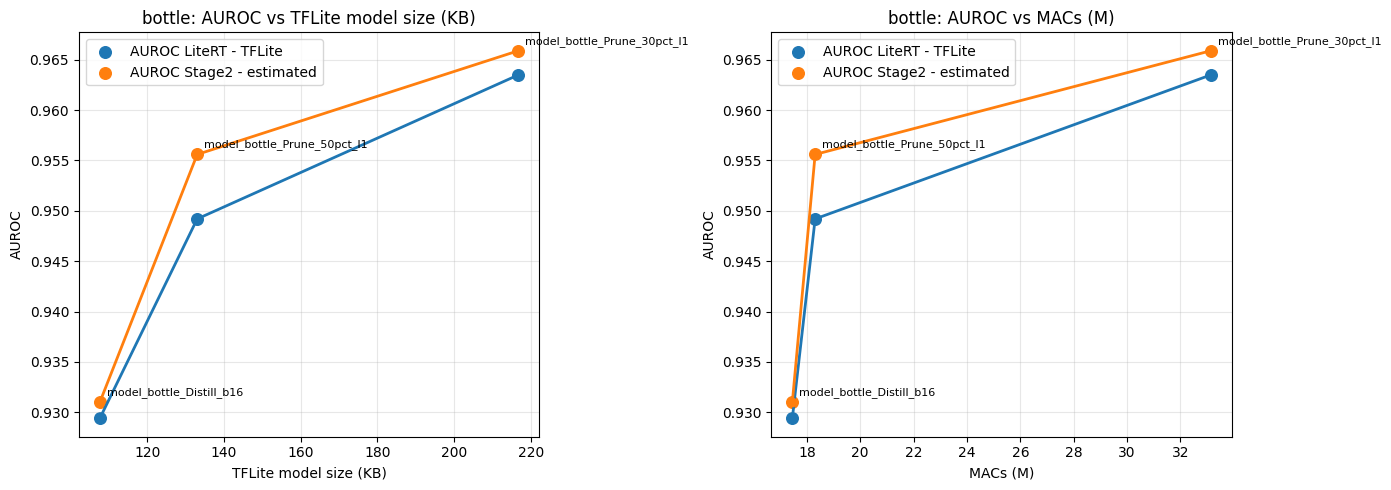

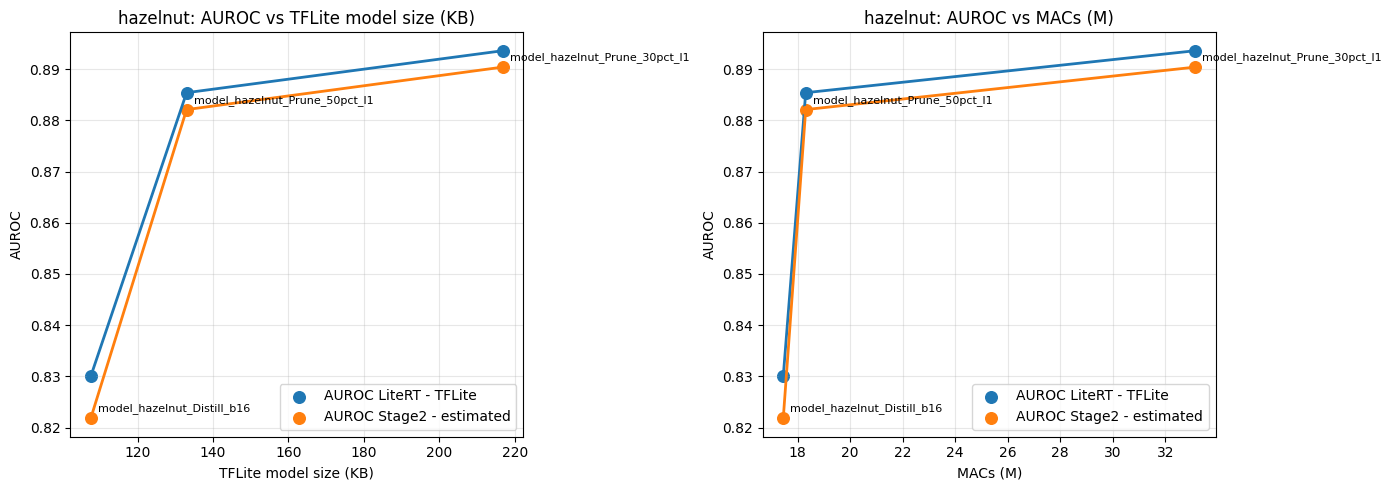

In [33]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def pareto_front(points):
    pts = sorted(points, key=lambda p: p[0])  # sort by cost (ascending)
    front = []
    best = -float("inf")

    for x, y, n in pts:
        if y > best:
            front.append((x, y, n))
            best = y

    return front


# ------------------------------------------------------------------
# Load results
# ------------------------------------------------------------------
df = pd.read_csv("/content/stage3_out/tflite_results.csv")

# MACs in millions
df["macs_M"] = df["macs"] / 1e6

# Labels for the legend
AUROC_LABELS = {
    "auroc_litert": "AUROC LiteRT - TFLite",
    "auroc_stage2": "AUROC Stage2 - estimated",
}

# ------------------------------------------------------------------
# Plot one figure per category
# ------------------------------------------------------------------
for category, df_cat in df.groupby("category"):

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, cost_col, xlabel in [
        (axes[0], "tflite_kb", "TFLite model size (KB)"),
        (axes[1], "macs_M", "MACs (M)"),
    ]:

        for auroc_col, color in [
            ("auroc_litert", "tab:blue"),
            ("auroc_stage2", "tab:orange"),
        ]:

            pts = [
                (row[cost_col], row[auroc_col], row["name"])
                for _, row in df_cat.iterrows()
            ]

            ax.scatter(
                [p[0] for p in pts],
                [p[1] for p in pts],
                color=color,
                s=70,
                label=AUROC_LABELS[auroc_col],
            )

            # Annotate only once to avoid duplicate labels
            if auroc_col == "auroc_stage2":
                for x, y, name in pts:
                    ax.annotate(
                        name,
                        (x, y),
                        fontsize=8,
                        xytext=(5, 5),
                        textcoords="offset points",
                    )

            front = pareto_front(pts)

            ax.plot(
                [p[0] for p in front],
                [p[1] for p in front],
                color=color,
                marker="o",
                linewidth=2,
                label="_nolegend_",  # Don't show Pareto fronts in legend
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel("AUROC")
        ax.set_title(f"{category}: AUROC vs {xlabel}")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"pareto_{category}.png", dpi=150, bbox_inches="tight")
    plt.show()

ondevice_results.csv uploaded to drive (`stage3_out`) and loaded to Workbook.

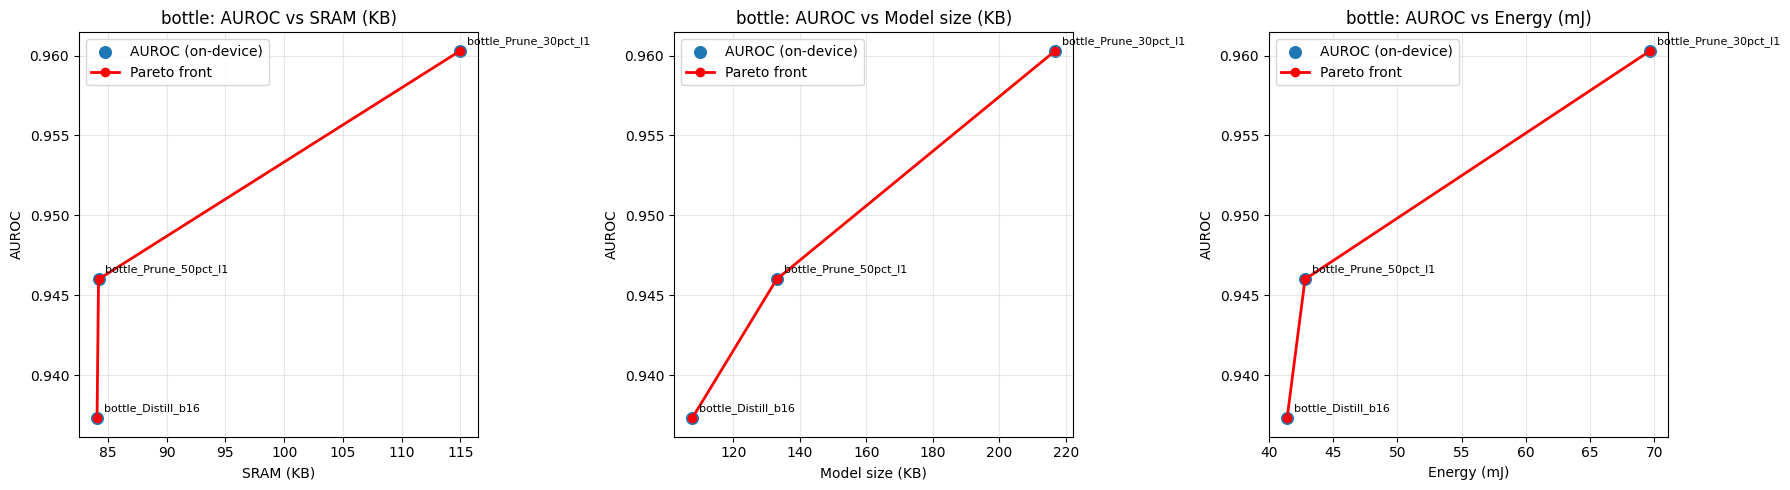

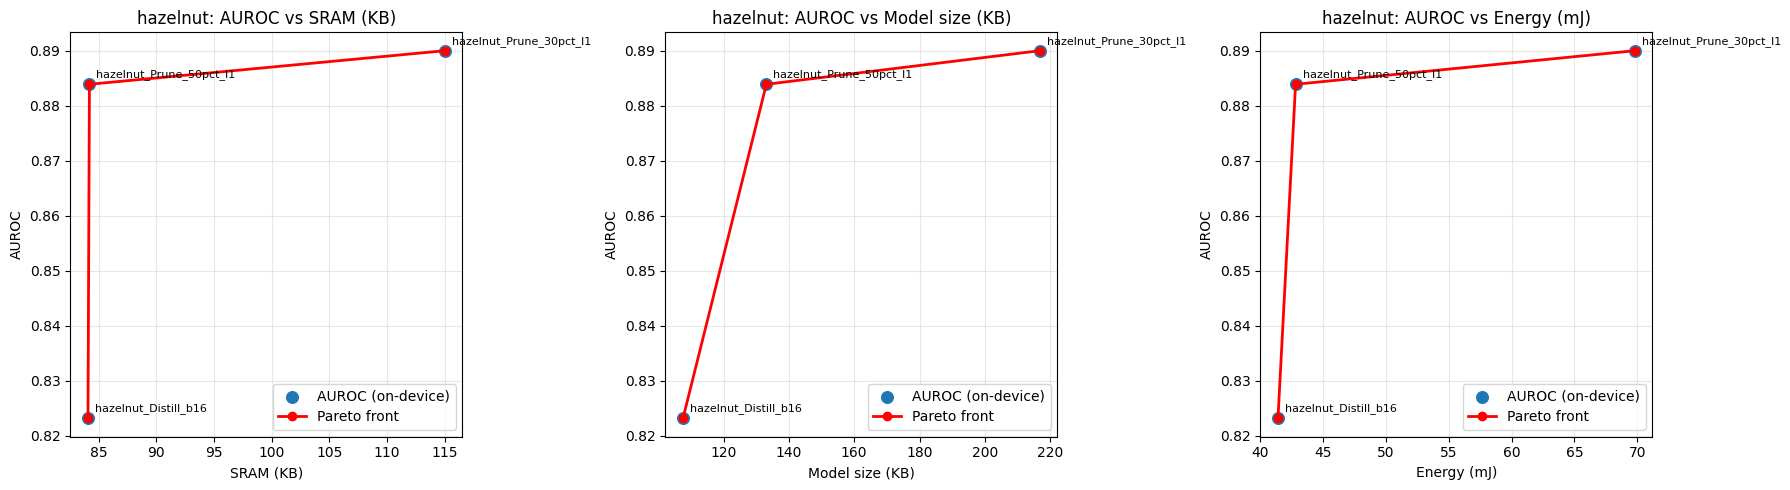

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def pareto_front(points):
    # remove invalid entries (NaN / None safety)
    points = [
        p for p in points
        if p[0] is not None and p[1] is not None
    ]

    pts = sorted(points, key=lambda p: p[0])  # minimize cost
    front = []
    best = -float("inf")

    for x, y, n in pts:
        if y > best:
            front.append((x, y, n))
            best = y

    return front


# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
df = pd.read_csv("/content/stage3_out/ondevice_results.csv")

# Safety cleanup (prevents matplotlib crashes)
df = df.dropna(subset=["auroc_ondevice", "SRAM_arena", "model_size", "energy_mJ"])

# Convert units
df["SRAM_KB"] = df["SRAM_arena"] / 1024
df["model_size_KB"] = df["model_size"] / 1024

AUROC_COL = "auroc_ondevice"
AUROC_LABEL = "AUROC (on-device)"

# ------------------------------------------------------------------
# Plot per category
# ------------------------------------------------------------------
for category, df_cat in df.groupby("category"):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    plots = [
        ("SRAM_KB", "SRAM (KB)"),
        ("model_size_KB", "Model size (KB)"),
        ("energy_mJ", "Energy (mJ)"),
    ]

    for ax, (cost_col, xlabel) in zip(axes, plots):

        pts = [
            (row[cost_col], row[AUROC_COL], row["model"])
            for _, row in df_cat.iterrows()
        ]

        # Scatter
        ax.scatter(
            [p[0] for p in pts],
            [p[1] for p in pts],
            s=70,
            label=AUROC_LABEL,
        )

        # Labels
        for x, y, name in pts:
            ax.annotate(
                name,
                (x, y),
                fontsize=8,
                xytext=(5, 5),
                textcoords="offset points",
            )

        # Pareto front
        front = pareto_front(pts)
        ax.plot(
            [p[0] for p in front],
            [p[1] for p in front],
            "r-o",
            linewidth=2,
            label="Pareto front",
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel("AUROC")
        ax.set_title(f"{category}: AUROC vs {xlabel}")
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.savefig(f"pareto_ondevice_{category}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Zone 3 — On-Device (Half B)
*C++ firmware for the Arduino in /Ondevice_Inference/ folder.*

## 11. Arduino setup

**Board:** Arduino Nano 33 BLE Sense Rev 2.  
**Library:** install `Arduino_TensorFlowLite`: https://github.com/tensorflow/tflite-micro-arduino-examples. Import the .zip to Arduino IDE.

**Project files for /arduino_stage3_OneModelInference/**:
- `arduino_stage3_OneModelInference.ino`
- `model_bottle_prune50.h` — a converted model header (start with one)
- `test_img_good.h`, `test_img_defect.h` — the test images

**Project files for /arduino_stage3_StreamTestSet/**:

- `arduino_stage3_StreamTestSet.ino` — Arduino firmware that streams the full test set, runs inference, and logs latency/SRAM/flash usage per sample
- `streamTestSet.py` — Python script that sends test images over serial, collects predictions, and computes AUROC on-device
- `bottle_testset_int8.npz` — INT8-quantized test dataset for the bottle category (NumPy archive of images + labels)
- `hazelnut_testset_int8.npz` — INT8-quantized test dataset for the hazelnut category (NumPy archive of images + labels)
- `ondevice_results.csv` — logged results from the Arduino (per-sample inference time, predicted score, memory stats)

# Stage 3 — Report & Stage 4 Handoff

## What Stage 3 produces

- TFLite INT8 models for each deployment candidate, with **verified** AUROC (TFLite vs PyTorch) and **real** model size (replaces Stage 2's theoretical estimate).
- On-device measurements: latency, SRAM (arena), flash, and approximated energy per inference.
- The Stage 2 Pareto plot, re-drawn with **measured** size/MACs on the cost axis instead of estimated.
- Pareto plot with ondevice measurements SRAM/ Model size (flash)/ energy

## Insights

- **Conversion can change AUROC slightly.** Full INT8 (activations too, not just weights as in Stage 2's simulation) --> shifted AUROC down by max. 3 thousandths

## Stage 4 — handoff

Stage 4 (energy-aware adaptation) needs:

1. **The measured energy per inference** for each model
2. **The accuracy of each model**

In Stage 4 it is evaluated, according to the energy budget (simulated battery), energy per inference and battery, which policy (wheter it is static or adaptive) gives the best trade-off.